## Libraries

In [1]:
# import libraries 
import numpy as np
import scipy as sp
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import math
import random
import seaborn as sns

## Square and Triangular Lattices

In [2]:
def _closest_square_factors(n: int) -> tuple[int, int]:
    """
    Find an exact factorization n = rows * cols, as close to a square as possible.
    Raises if n is prime, because then an exact 2D rectangular grid is impossible.
    """
    for rows in range(int(math.sqrt(n)), 1, -1):
        if n % rows == 0:
            return rows, n // rows
    raise ValueError(
        f"n={n} cannot be written as rows*cols with both > 1, "
        "so an exact square lattice with n nodes is not possible."
    )


def _triangular_node_count(m: int, k: int) -> int:
    """
    Exact node count returned by nx.triangular_lattice_graph(m, k, periodic=False).
    """
    return math.ceil((m + 1) * (k + 2) / 2)


def _best_triangular_dims(n: int) -> tuple[int, int]:
    """
    Find m, k such that triangular_lattice_graph(m, k) has exactly n nodes,
    preferring shapes that are as balanced as possible.
    """
    best = None

    for m in range(1, n + 1):
        # From ceil((m+1)(k+2)/2) ≈ n
        k0 = max(1, int(round((2 * n) / (m + 1) - 2)))

        for k in range(max(1, k0 - 3), k0 + 4):
            if _triangular_node_count(m, k) == n:
                score = abs(m - k)  # prefer more balanced shapes
                if best is None or score < best[0]:
                    best = (score, m, k)

    if best is None:
        raise ValueError(f"Could not find a triangular lattice with exactly n={n} nodes.")

    return best[1], best[2]


def newman_watts_lattice_graph(n: int, p: float, type: str = "square", seed=None) -> nx.Graph:
    """
    Newman–Watts-style small-world graph starting from a square or triangular lattice.

    Parameters
    ----------
    n : int
        Total number of nodes.
    p : float
        Probability of adding one shortcut per original edge.
    type : str
        "square" or "triangular".
    seed : int | None
        Random seed.

    Returns
    -------
    G : nx.Graph
        Undirected graph with integer labels 0..n-1.
        Original lattice coordinates are stored in node attribute 'coord'.
        Plot positions are stored in node attribute 'pos'.
    """
    if n < 3:
        raise ValueError("n must be at least 3.")
    if not (0 <= p <= 1):
        raise ValueError("p must be in [0, 1].")

    rng = random.Random(seed)
    type = type.lower()

    # 1) Build the base lattice with prebuilt NetworkX generators
    if type == "square":
        rows, cols = _closest_square_factors(n)
        G = nx.grid_2d_graph(rows, cols, periodic=False)

        # add plotting positions
        pos = {node: (node[1], -node[0]) for node in G.nodes()}
        nx.set_node_attributes(G, pos, "pos")

    elif type == "triangular":
        m, k = _best_triangular_dims(n)
        G = nx.triangular_lattice_graph(m, k, periodic=False, with_positions=True)

    else:
        raise ValueError("type must be 'square' or 'triangular'.")

    # 2) Relabel nodes to integers, but keep original coordinates
    G = nx.convert_node_labels_to_integers(G, ordering="default", label_attribute="coord")

    # 3) Newman–Watts step:
    #    for each ORIGINAL edge, with probability p add a random shortcut
    base_edges = list(G.edges())
    nodes = list(G.nodes())

    for u, v in base_edges:
        if rng.random() < p:
            candidates = [w for w in nodes if w != u and not G.has_edge(u, w)]
            if candidates:
                w = rng.choice(candidates)
                G.add_edge(u, w)

    return G

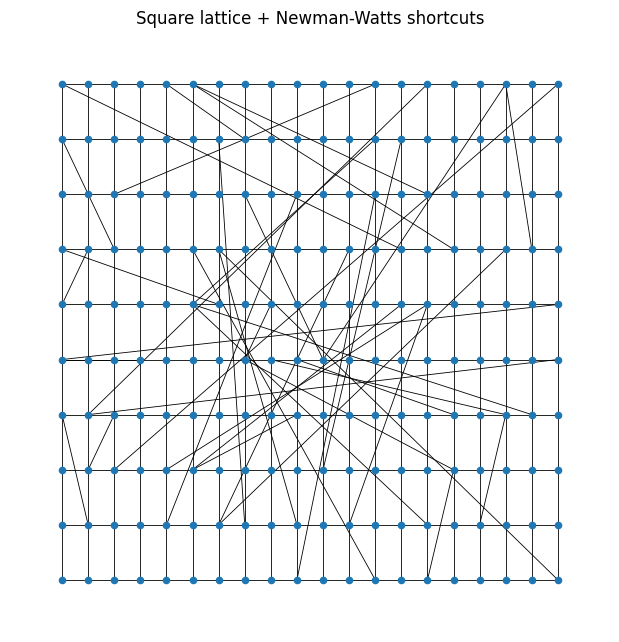

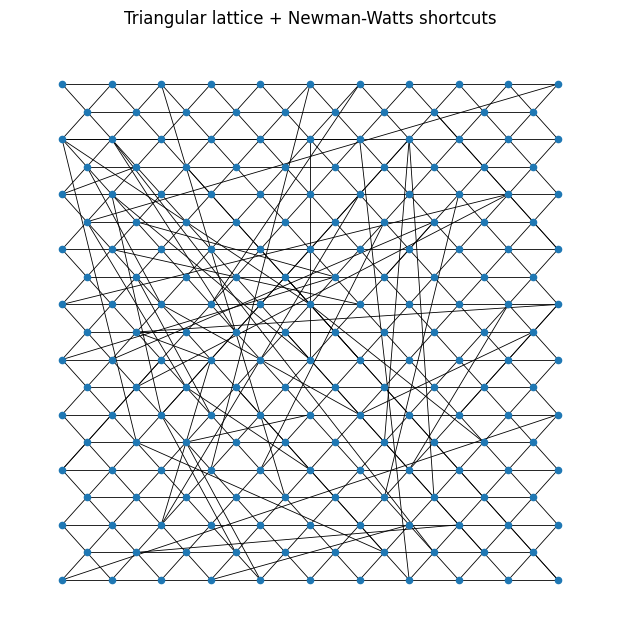

In [3]:
G1 = newman_watts_lattice_graph(200, 0.1, type="square", seed=42)
G2 = newman_watts_lattice_graph(200, 0.1, type="triangular", seed=42)

plt.figure(figsize=(6, 6))
nx.draw(G1, pos=nx.get_node_attributes(G1, "pos"), node_size=20, width=0.6)
plt.title("Square lattice + Newman-Watts shortcuts")
plt.show()

plt.figure(figsize=(6, 6))
nx.draw(G2, pos=nx.get_node_attributes(G2, "pos"), node_size=20, width=0.6)
plt.title("Triangular lattice + Newman-Watts shortcuts")
plt.show()

## Parameters

In [4]:
# Create an empty graph
G = nx.Graph()

# Add nodes
nodes = range(1, 17)
G.add_nodes_from(nodes)

# Add edges based on the visual structure
edges = [
    (1, 2), (1, 3), (1, 4), (2, 4), (2,5), (3, 4), (3, 6), (3, 7), (3, 8), (4, 5), (4, 8), (4, 9),
    (5, 9), (6, 7), (7, 8), (7, 11), (7, 10), (7, 13), (8, 9), (8, 11), (8, 12), (9, 12),
    (10, 13), (11, 12), (11, 13), (11, 14), (12, 14), (12, 15), (13, 14), (13, 16) ,(14, 15),
    (14, 16), (15, 16)
]
G.add_edges_from(edges)

# Set parameters
alpha = 0.0050415
beta = 0.000013047
delta = 0.0079639
do = 0.0017783
numerator = 2 * delta**2 * beta + do * (alpha + beta)**2 + 2 * (alpha + beta) * delta * np.sqrt(2 * do * (alpha + beta))
denominator = 2 * alpha * delta**2
Ic = numerator / denominator
I = Ic + 0.01

# Critical eigenvalue, must be 1.19198455
lambda_c = (do * (alpha + beta)**2 + 2 * beta * delta**2 - 2 * I * alpha * delta**2) / (4 * do * delta * (alpha + beta))

# Compute the homogeneous steady states
rho_ss = alpha * delta / (alpha + beta)
O_ss = (alpha + beta) / delta
params = {
    'alpha': alpha,
    'beta': beta,
    'delta': delta,
    'do': do,
    'I': I,
    'rho_ss': rho_ss,
    'O_ss': O_ss,
    'lambda_c': lambda_c
}

In [5]:
params

{'alpha': 0.0050415,
 'beta': 1.3047e-05,
 'delta': 0.0079639,
 'do': 0.0017783,
 'I': np.float64(0.6174034423516578),
 'rho_ss': 0.007943343261028139,
 'O_ss': 0.6346823792363039,
 'lambda_c': np.float64(-1.2144640658690309)}

## Dispertion Relation

In [6]:
def dispertion_relation(params, plot=False, eigenvalues: list=None, index_critical_eigenvalue: int=None):
    """
    Function to get the dispersion relation of the graph
    """
    # Parameters
    alpha = params['alpha']
    beta = params['beta']
    delta = params['delta']
    do = params['do']
    I = params['I']
    rho_ss = params['rho_ss']
    O_ss = params['O_ss']
    lambda_c = params['lambda_c']
    
        # Define a suitable range of lambda values
    lambda_vals = np.linspace(-8, 0, 500)

    # b(λ)
    def b(lambda_N):
        return ((alpha + beta)/delta
                + (delta * beta)/(alpha + beta)
                - lambda_N * (2 + do))

    # c(λ)
    def c(lambda_N):
        return (
            2 * do * (lambda_N**2)
            + lambda_N * (
                (2 * I * alpha * delta) / (alpha + beta)
                - (2 * delta * beta) / (alpha + beta)
                - (do * (alpha + beta)) / delta
            )
            + (alpha + beta)
        )

    # η(λ) = -b(λ)/2 + (1/2)*sqrt(b(λ)^2 - 4 c(λ))
    def eta(lambda_N):
        return -0.5 * b(lambda_N) + 0.5 * np.sqrt(b(lambda_N)**2 - 4 * c(lambda_N))

    # Evaluate eta on the grid of lambda values
    eta_vals = eta(lambda_vals)

    # Extract only the real part
    eta_vals_real = np.real(eta_vals)

    # Determine the range for positive values
    positive_range = np.where(eta_vals_real > 0)[0]

    min_lambda = lambda_vals[positive_range[0]]
    max_lambda = lambda_vals[positive_range[-1]]

    if plot: 
        # Plot the real part of eta vs. lambda
        plt.figure()
        plt.plot(lambda_vals, eta_vals_real, label=r'Real[$\eta(\lambda)$]')
        # Graph a horizontal line at 0
        plt.axhline(0, color='black', linestyle='-')
        
        # Plot eigenvalues if provided
        if eigenvalues is not None:
            # Plot eigenvalues as asterisks on x-axis
            plt.plot(eigenvalues, [0] * len(eigenvalues), '*', color='red', 
                    markersize=10, label='Eigenvalues')
            
            # If index of critical eigenvalue is provided, highlight it
            if index_critical_eigenvalue is not None:
                plt.plot(eigenvalues[index_critical_eigenvalue], 0, '*', 
                        color='green', markersize=15, 
                        label='Critical Eigenvalue')
        
        plt.xlabel(r'$\lambda$')
        plt.ylabel(r'Real[$\eta(\lambda)$]')
        plt.title('Dispersion Relation')
        plt.legend()
        plt.grid(True)
        plt.show()

    return {
        'min_lambda': float(min_lambda),
        'max_lambda': float(max_lambda),
        'function': eta,
    }

    

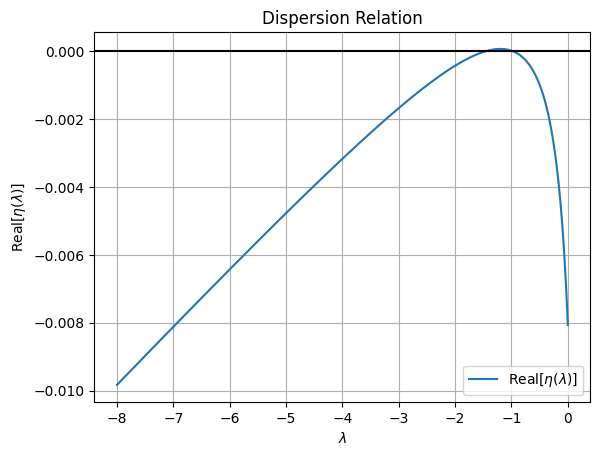

{'min_lambda': -1.4428857715430867,
 'max_lambda': -0.9939879759519048,
 'function': <function __main__.dispertion_relation.<locals>.eta(lambda_N)>}

In [7]:
dispertion_relation(params, plot=True)

## Dynamics

In [8]:
# Set of functions



def get_dynamics(graph, params, plot=False, integration=True):
    """
    Function to get the dynamics of the graph
    """
    # Parameters
    alpha = params['alpha']
    beta = params['beta']
    delta = params['delta']
    do = params['do']
    I = params['I']
    rho_ss = params['rho_ss']
    O_ss = params['O_ss']
    lambda_c = params['lambda_c']
    G = graph
    n = G.number_of_nodes()
    e = G.number_of_edges()
    A = nx.adjacency_matrix(G).todense()

    
    def system(t, y, A, alpha, beta, delta, do, I):
        """
        y[k][0] is rho
        y[k][1] is O
        n repetitions for each municipality
        2 variables, rho and O
        """


        y = y.reshape(n, 2)
        
        dydt = np.zeros_like(y)

        

        def function_1(j):
            return A[i][j] * (y[j][0] - y[i][0])
        
        def function_2(j):
            return A[i][j] * ((y[i][1]/y[j][1])**I * y[j][0] - (y[j][1]/y[i][1])**I * y[i][0])
        
        def function_3(j):
            return A[i][j] * (y[j][1] - y[i][1])
        
        j = np.arange(16)
        

        for i in range(n):
            f_1_j = np.vectorize(function_1)(j)
            f_2_j = np.vectorize(function_2)(j)
            f_3_j = np.vectorize(function_3)(j)
            dydt[i, 0] = -y[i, 0] * y[i, 1] + alpha + np.sum(f_1_j) + np.sum(f_2_j)
            dydt[i, 1] = -delta * y[i, 1] + beta + y[i, 0] * y[i, 1] + do * np.sum(f_3_j)

        return dydt.flatten()
    # Initial conditions
    np.random.seed(0)
    y0 = np.array([rho_ss, O_ss] * n) + np.random.uniform(-0.01, 0.01, n * 2) * np.array([rho_ss, O_ss] * n)

    # Time span
    t_span = (0, 1000000)
    

    # Solve the system of ODEs
    print("Starting the integration...")
    if integration:
        t_eval = np.linspace(*t_span, 1000)
        solution = sp.integrate.solve_ivp(system, t_span, y0, method='BDF', args=(A, alpha, beta, delta, do, I), t_eval=t_eval)
        print("Integration finished.")
        t = solution.t
        y = solution.y.reshape(n, 2, -1)
    else:
        print("Integration skipped. Filling dynamics-dependent values with NaN.")
        # Dummy time and dynamics
        t = np.array([np.nan])
        y = np.full((n, 2, 1), np.nan)

    # Plot full dynamics (rho and O) for each node
    if plot and integration:
        fig_dyn, axes_dyn = plt.subplots(n, 2, figsize=(10, 2.2 * n), sharex=True)
        for i in range(n):
            axes_dyn[i, 0].plot(t, y[i, 0], color='C0')
            axes_dyn[i, 0].axhline(rho_ss, color='red', linestyle='--', linewidth=0.8)
            axes_dyn[i, 0].set_ylabel(f'Node {i + 1}')
            axes_dyn[i, 1].plot(t, y[i, 1], color='C1')
            axes_dyn[i, 1].axhline(O_ss, color='red', linestyle='--', linewidth=0.8)
        axes_dyn[-1, 0].set_xlabel('Time')
        axes_dyn[-1, 1].set_xlabel('Time')
        axes_dyn[0, 0].set_title(r'$\rho(t)$')
        axes_dyn[0, 1].set_title(r'$O(t)$')
        plt.tight_layout()
        plt.show()

    # Extract the stationary state from the dynamics (the last values)
    nodes = np.arange(1, n + 1)
    if integration:
        last_values_rho = np.zeros(n)
        last_values_O = np.zeros(n)
        for i in range(n):
            last_values_rho[i] = y[i, 0][-1]
            last_values_O[i] = y[i, 1][-1]
    else:
        last_values_rho = np.full(n, np.nan)
        last_values_O = np.full(n, np.nan)

    print("Linear algebra computations...")
    # Computing the spectrum of the Laplacian matrix
    L = -1 * nx.laplacian_matrix(G).todense()
    L = np.asarray(L, dtype=float)
    L = (L + L.T) / 2
    eigenvalues, eigenvectors = np.linalg.eigh(L)
    # sort eigenvalues and eigenvectors
    idx = eigenvalues.argsort()
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:,idx]

    
    # the function eta is dispertion_relation(params)['function']
    # Evaluate eta on the eigenvalues
    eta_function = dispertion_relation(params)['function']
    eta_eigenvalues = eta_function(eigenvalues)
    # get the real part of the maximum eta eigenvalue
    eta_eigenvalues = np.real(eta_eigenvalues)
    # get the max growth rate
    max_eta = np.max(eta_eigenvalues)
    if max_eta >= 0:
        linear_analysis = True
    else:
        linear_analysis = False
    #  get the eigenvalue that maximizes the growth rate except the last
    max_eta_index = np.argmax(eta_eigenvalues[:-1])
    max_eta_eigenvalue = eigenvalues[max_eta_index]



    # # get the index of the nearest eigenvalue to lambda_c
    # index_lambda_c = np.argmin(np.abs(eigenvalues - lambda_c))
    # # the index cannot be zero 
    # min_lambda, max_lambda = dispertion_relation(params).values()
    # # check if the index is in the range
    # critical_eigenvalue = eigenvalues[index_lambda_c]
    # linear_analysis = True
    
    # if critical_eigenvalue < min_lambda or critical_eigenvalue > max_lambda:
    #     linear_analysis = False
    
    # if linear_analysis:
    #     critical_eigenvector = eigenvectors[:, index_lambda_c]
        
    # else: 
    #     # set critical eigenvector as zero vector
    #     critical_eigenvector = None
    #     print("The critical eigenvalue is not in the range of the dispersion relation.")
    #     print("The linear analysis cannot be performed.")
    #     print("The critical eigenvalue is: ", critical_eigenvalue)

    # substitution 
    critical_eigenvalue = max_eta_eigenvalue
    index_lambda_c = max_eta_index
    dispertion_relation(params, plot=plot, eigenvalues=eigenvalues, index_critical_eigenvalue=index_lambda_c)
    critical_eigenvector = eigenvectors[:, index_lambda_c]
    # Inverse Participation Ratio (IPR)
    if integration:
        ipr_rho = np.sum(last_values_rho**4) / (np.sum(last_values_rho**2)**2)
        ipr_O = np.sum(last_values_O**4) / (np.sum(last_values_O**2)**2)
    else:
        ipr_rho = np.nan
        ipr_O = np.nan

    ipr_eigenvector = np.sum(critical_eigenvector**4) / (np.sum(critical_eigenvector**2)**2)
    variance_eigenvector = float(np.var(critical_eigenvector))

    # IPR of all eigenvectors
    IPR_all_eigenvectors = [np.sum(eigenvectors[:, i]**4) / (np.sum(eigenvectors[:, i]**2)**2) for i in range(n)]

    if plot:
        
        # Creating the stem plots
        fig, axes = plt.subplots(4, 1, figsize=(10, 10))

        # Plot eigenvalues vs IPR
        axes[0].plot(eigenvalues, IPR_all_eigenvectors, 'ko-')
        # Mark critical eigenvalue with green star
        axes[0].plot(eigenvalues[index_lambda_c], IPR_all_eigenvectors[index_lambda_c], 'g*', markersize=15, label='Critical eigenvalue')
        axes[0].set_xlabel('Eigenvalues')
        axes[0].set_ylabel('IPR')
        axes[0].legend()

        # Stem plots for rho and O (will be NaN if no integration)
        axes[1].stem(nodes, last_values_rho, linefmt='gray', markerfmt='ko', basefmt=' ', bottom=rho_ss)
        axes[1].axhline(rho_ss, color='red', linestyle='--')
        axes[1].set_xlabel('Nodes')
        axes[1].set_ylabel(r'$\rho$')

        axes[2].stem(nodes, last_values_O, linefmt='gray', markerfmt='ko', basefmt=' ', bottom=O_ss)
        axes[2].axhline(O_ss, color='red', linestyle='--')
        axes[2].set_xlabel('Nodes')
        axes[2].set_ylabel(r'$O$')

        axes[3].stem(nodes, critical_eigenvector, linefmt='gray', markerfmt='ko', basefmt=' ')
        axes[3].axhline(0, color='red', linestyle='--')
        axes[3].set_xlabel('Nodes')
        axes[3].set_ylabel('Eigenvector')

        plt.tight_layout()
        plt.show()

    # Variance 
    if integration:
        variance_rho = np.var(last_values_rho)
        variance_O = np.var(last_values_O)
    else:
        variance_rho = np.nan
        variance_O = np.nan

    # Network average degree
    k_avg = 2 * e / n

    # Degree of each node 
    degrees = np.array([val for (node, val) in G.degree()])
    
    # Local clustering for each node 
    clustering_coeffs = np.array([val for (node, val) in nx.clustering(G).items()])
    avg_clustering = np.mean(clustering_coeffs)

    # Probability distribution based on value of eigenvectors
    P_i = np.array([[z ** 2/np.sum(eigenvectors[:, i] ** 2) for z in eigenvectors[:, i]] for i in range(n)])

    # Compute weighted average degree and clustering
    weighted_k_avg = np.array([np.sum(degrees * P_i[i]) for i in range(n)])
    weighted_clustering = np.array([np.sum(clustering_coeffs * P_i[i]) for i in range(n)])

    # Probability distribution based on value of last values of rho and O
    if integration:
        P_i_rho = last_values_rho**2 / np.nansum(last_values_rho**2)
        P_i_O = last_values_O**2 / np.nansum(last_values_O**2)

        # Compute weighted average degree and clustering based on rho and O
        weighted_k_avg_rho = np.sum(degrees * P_i_rho)
        weighted_clustering_rho = np.sum(clustering_coeffs * P_i_rho)
        weighted_k_avg_O = np.sum(degrees * P_i_O)
        weighted_clustering_O = np.sum(clustering_coeffs * P_i_O)

        # Compute entropy of rho and O distributions
        entropy_rho = -np.sum(P_i_rho * np.log(P_i_rho + 1e-10))
        entropy_O = -np.sum(P_i_O * np.log(P_i_O + 1e-10))
    else:
        P_i_rho = np.full(n, np.nan)
        P_i_O = np.full(n, np.nan)
        weighted_k_avg_rho = np.nan
        weighted_clustering_rho = np.nan
        weighted_k_avg_O = np.nan
        weighted_clustering_O = np.nan
        entropy_rho = np.nan
        entropy_O = np.nan

    print("Computations finished.")
    
    # Plot avg degree and clustering vs eigenvalues
    if plot:
        # First plot: Weighted Average Degree
        plt.figure(figsize=(10, 4))
        plt.plot(eigenvalues/k_avg, weighted_k_avg/k_avg, 'ko-')
        plt.axvline(x=-1, color='black', linestyle='--')
        plt.axhline(y=1, color='black', linestyle='--')
        plt.xlabel(r'$\lambda/\langle k \rangle$')
        plt.ylabel(r'$\langle k_c \rangle/\langle k \rangle$')
        plt.grid(True)
        plt.show()

        # Second plot: Weighted Clustering
        plt.figure(figsize=(10, 4))
        plt.plot(eigenvalues/k_avg, weighted_clustering/avg_clustering, 'ko-')
        plt.axvline(x=-1, color='black', linestyle='--')
        plt.axhline(y=1, color='black', linestyle='--')
        plt.xlabel(r'$\lambda/\langle k \rangle$')
        plt.ylabel(r'$\langle C_c \rangle/\langle C \rangle$')
        plt.grid(True)
        plt.show()

    # plot all the eigenvectors
    if plot:
        plt.figure(figsize=(10, 6))
        for i in range(n):
            plt.plot(eigenvectors[:, i], label=f'Eigenvector {i+1}')
        plt.xlabel('Nodes')
        plt.ylabel('Eigenvector Components')
        plt.title('All Eigenvectors')
        plt.legend()
    # Return the results
    return {
        'critical_eigenvalue': float(eigenvalues[index_lambda_c]),
        'last_values_rho': last_values_rho.tolist(),
        'last_values_O': last_values_O.tolist(),
        'critical_eigenvector': critical_eigenvector.tolist() if critical_eigenvector is not None else None,
        'eigenvectors': eigenvectors.tolist(),
        'eigenvalues': eigenvalues.tolist(),
        'variance_rho': float(variance_rho) if not np.isnan(variance_rho) else np.nan,
        'variance_O': float(variance_O) if not np.isnan(variance_O) else np.nan,
        'variance_eigenvector': variance_eigenvector,
        'ipr_rho': float(ipr_rho) if not np.isnan(ipr_rho) else np.nan,
        'ipr_O': float(ipr_O) if not np.isnan(ipr_O) else np.nan,
        'ipr_eigenvector': ipr_eigenvector,
        'k_avg': float(k_avg),
        'avg_clustering': float(avg_clustering),
        'weighted_k_avg': weighted_k_avg.tolist(),
        'weighted_clustering': weighted_clustering.tolist(),
        'IPR_all_eigenvectors': IPR_all_eigenvectors,
        'linear_analysis': linear_analysis,
        'entropy_rho': float(entropy_rho) if not np.isnan(entropy_rho) else np.nan,
        'entropy_O': float(entropy_O) if not np.isnan(entropy_O) else np.nan,
        'weighted_k_avg_rho': float(weighted_k_avg_rho) if not np.isnan(weighted_k_avg_rho) else np.nan,
        'weighted_clustering_rho': float(weighted_clustering_rho) if not np.isnan(weighted_clustering_rho) else np.nan,
        'weighted_k_avg_O': float(weighted_k_avg_O) if not np.isnan(weighted_k_avg_O) else np.nan,
        'weighted_clustering_O': float(weighted_clustering_O) if not np.isnan(weighted_clustering_O) else np.nan,
    }


Starting the integration...
Integration skipped. Filling dynamics-dependent values with NaN.
Linear algebra computations...


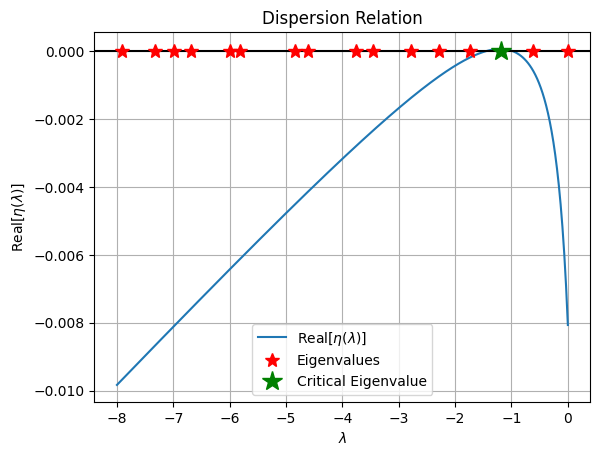

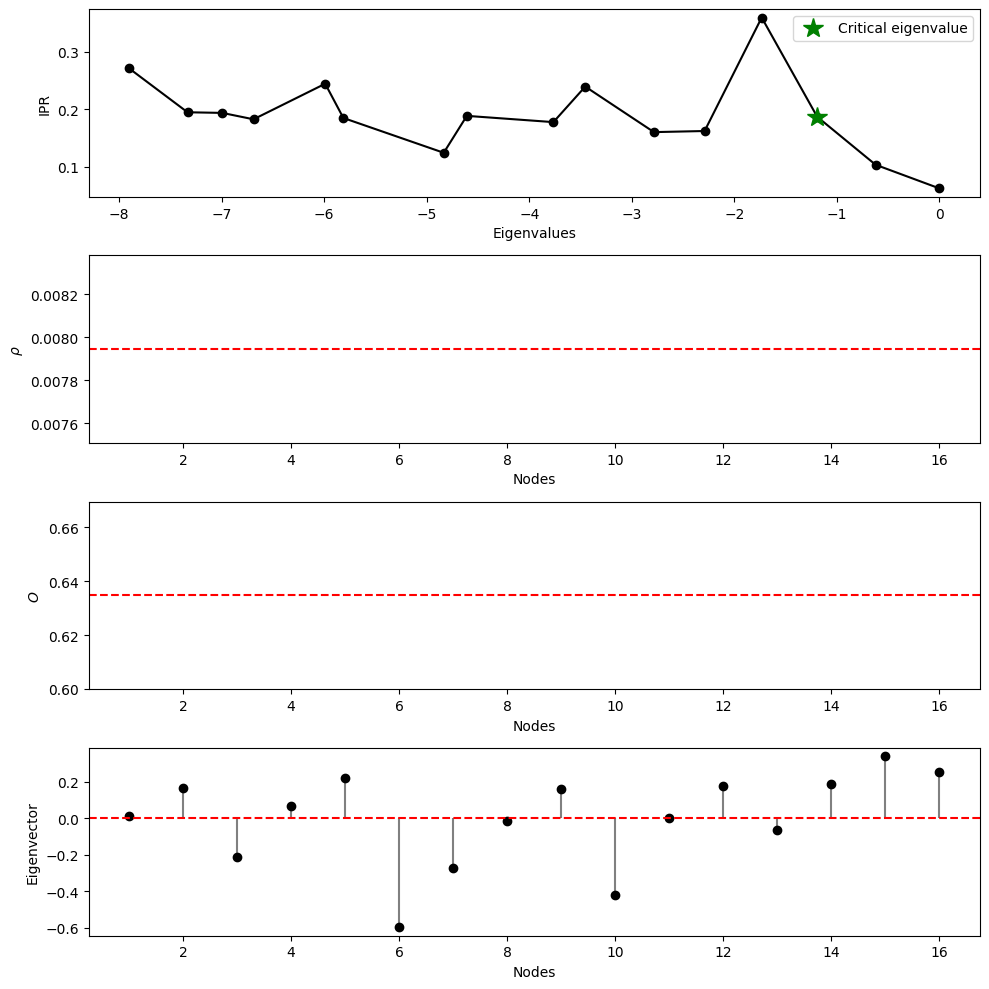

Computations finished.


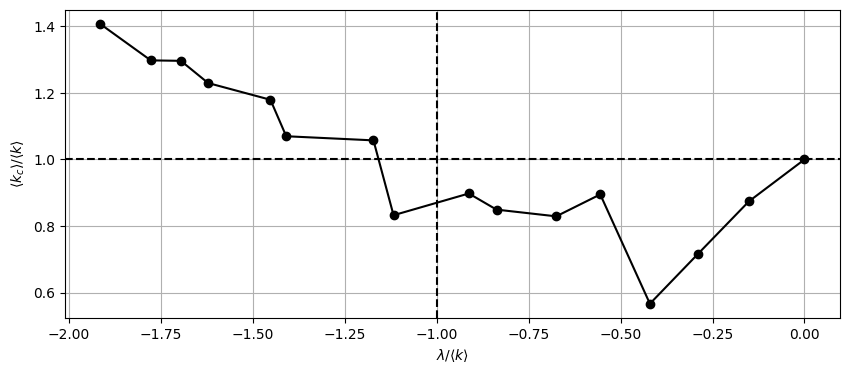

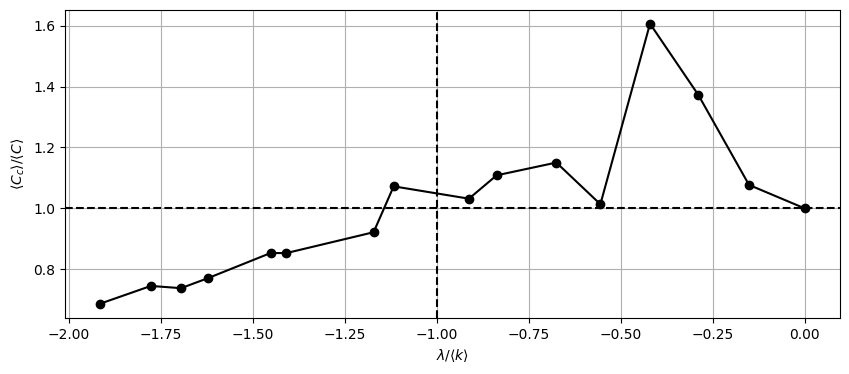

{'critical_eigenvalue': -1.1921312788152183,
 'last_values_rho': [nan,
  nan,
  nan,
  nan,
  nan,
  nan,
  nan,
  nan,
  nan,
  nan,
  nan,
  nan,
  nan,
  nan,
  nan,
  nan],
 'last_values_O': [nan,
  nan,
  nan,
  nan,
  nan,
  nan,
  nan,
  nan,
  nan,
  nan,
  nan,
  nan,
  nan,
  nan,
  nan,
  nan],
 'critical_eigenvector': [0.014136992519185074,
  0.16672971189158314,
  -0.21017903177304456,
  0.06900714646851909,
  0.2182812920332395,
  -0.5960491453376606,
  -0.2713504290341742,
  -0.01607872555334694,
  0.15888706192659197,
  -0.41765605547962914,
  0.0014065523114410085,
  0.17492429843621607,
  -0.06606083440123597,
  0.1839216571039875,
  0.3379522188017861,
  0.2521272900865408],
 'eigenvectors': [[0.0678263478145925,
   0.10684156543940784,
   -0.061847427999360445,
   -0.015793360162466973,
   0.2179838859350783,
   0.02545829848825125,
   -0.43201721062183174,
   -0.231891445058285,
   -0.21237799981637248,
   0.11084299636616703,
   -0.43592376794367715,
   0.51021911

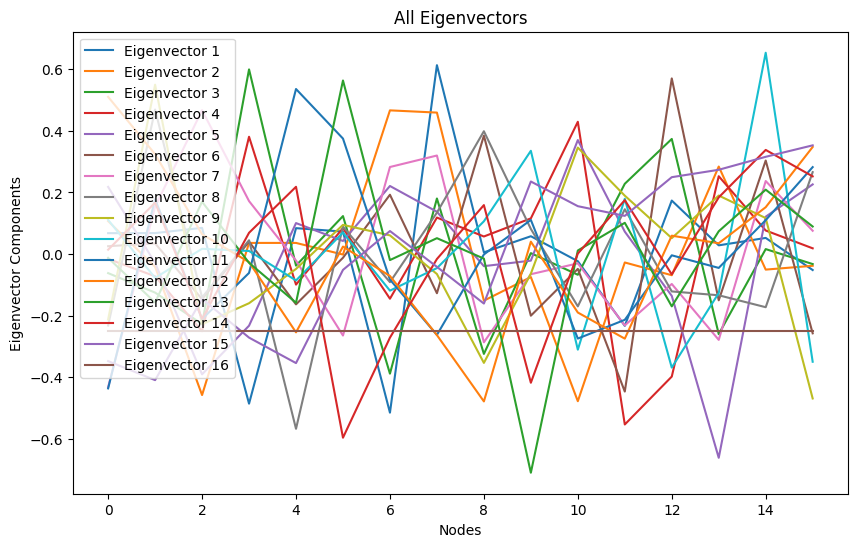

In [9]:
get_dynamics(G, params, plot=True, integration=False)

## Experiments with pandas

In [10]:
import pandas as pd
from multiprocessing import Pool

def process_graph(args):
    """Helper function to process a single graph with given parameters"""
    p, seed, n_nodes, params, type = args

    graph = newman_watts_lattice_graph(n=n_nodes, p=p, seed=seed, type=type)
    if type == "square":
        n_neighbors = 4
    elif type == "triangular":
        n_neighbors = 6
    max_clustering = 3/4 * (n_neighbors - 2) / (n_neighbors - 1)
    max_length = n_nodes / (2 * n_neighbors)
    
    transitivity = nx.transitivity(graph) / max_clustering
    avg_length = nx.average_shortest_path_length(graph) / max_length
    
    dynamics = get_dynamics(graph, params, integration=False)

    avg_degree = dynamics["k_avg"]
    transitivity_random = (avg_degree / n_nodes) / max_clustering
    avg_length_random = (np.log(n_nodes) / np.log(avg_degree)) / max_length
    sigma = (transitivity / transitivity_random) / (avg_length / avg_length_random)

    max_degree = max(dict(graph.degree()).values())
    hub_ness = max_degree / avg_degree

    avg_clustering = dynamics["avg_clustering"]
    weighted_k_avg = dynamics["weighted_k_avg"]
    weighted_clustering = dynamics["weighted_clustering"]
    
    return {
        'p': p,
        'seed': seed,
        'n_nodes': n_nodes,
        'n_neighbors': n_neighbors,
        'transitivity': transitivity,
        'avg_length': avg_length,
        'sigma': sigma,
        'hub_ness': hub_ness,
        'ipr_rho': dynamics['ipr_rho'],
        'ipr_O': dynamics['ipr_O'],
        'ipr_eigenvector': dynamics['ipr_eigenvector'],
        'variance_rho': dynamics['variance_rho'],
        'variance_O': dynamics['variance_O'],
        'variance_eigenvector': dynamics['variance_eigenvector'],
        'k_avg': dynamics['k_avg'],
        'avg_clustering': avg_clustering,
        'eigenvalues': dynamics['eigenvalues'],
        'critical_eigenvector': dynamics['critical_eigenvector'],
        'eigenvectors': dynamics['eigenvectors'],
        'IPR_all_eigenvectors': dynamics['IPR_all_eigenvectors'],
        'weighted_k_avg': weighted_k_avg,
        'weighted_clustering': weighted_clustering,
        'entropy_rho': dynamics['entropy_rho'],
        'entropy_O': dynamics['entropy_O'],
        'weighted_k_avg_rho': dynamics['weighted_k_avg_rho'],
        'weighted_clustering_rho': dynamics['weighted_clustering_rho'],
        'weighted_k_avg_O': dynamics['weighted_k_avg_O'],
        'weighted_clustering_O': dynamics['weighted_clustering_O'],
    }

def experiments(n_nodes, n_experiments, sample_size, params, type):
    print("Starting the experiments...")

    # sampling p values
    ring = np.linspace(0, 0.001, n_experiments // 3)
    small_world = np.linspace(0.05, 0.1, n_experiments // 3)
    random = np.linspace(0.9, 1.0, n_experiments // 3)
    p_values = np.concatenate([ring, small_world, random])  
    # p_values = np.linspace(0.09, 0.2, n_experiments)
    # p_values = np.logspace(-4, 0, n_experiments)
    # p_values = np.array([0.0, 0.1, 1.0])
    

    all_results = []

    with Pool() as pool:
        for i, p in enumerate(p_values):
            print(f"Computing graph {i + 1}/{n_experiments}...")
            args = [(p, seed, n_nodes, params, type) for seed in range(sample_size)]
            results = pool.map(process_graph, args)
            all_results.extend(results)

    df = pd.DataFrame(all_results)
    df['index_str'] = df.apply(lambda row: f"p{row['p']}_n{row['n_nodes']}_k{row['n_neighbors']}_seed{row['seed']}", axis=1)
    df.set_index('index_str', inplace=True)
    return df


In [29]:
import time
nodes = 200
experiments_num = 50
sample_size = 8
# Experiment data including hour 
experiment_time = time.strftime("%Y-%m-%d_%H-%M-%S")

experiment_df = experiments(nodes, experiments_num, sample_size, params, type="triangular")
experiment_df.head()

Starting the experiments...
Starting the integration...Starting the integration...Starting the integration...
Starting the integration...

Starting the integration...Integration skipped. Filling dynamics-dependent values with NaN.
Integration skipped. Filling dynamics-dependent values with NaN.Integration skipped. Filling dynamics-dependent values with NaN.

Integration skipped. Filling dynamics-dependent values with NaN.Integration skipped. Filling dynamics-dependent values with NaN.

Linear algebra computations...


Linear algebra computations...Linear algebra computations...

Linear algebra computations...Linear algebra computations...Starting the integration...

Starting the integration...
Integration skipped. Filling dynamics-dependent values with NaN.
Starting the integration...
Integration skipped. Filling dynamics-dependent values with NaN.Linear algebra computations...

Computing graph 1/50...

Integration skipped. Filling dynamics-dependent values with NaN.Linear algebra comp

,p,seed,n_nodes,n_neighbors,transitivity,avg_length,sigma,hub_ness,ipr_rho,ipr_O,...,eigenvectors,IPR_all_eigenvectors,weighted_k_avg,weighted_clustering,entropy_rho,entropy_O,weighted_k_avg_rho,weighted_clustering_rho,weighted_k_avg_O,weighted_clustering_O
index_str,,,,,,,,,,,,,,,,,,,,,
p0.0_n200_k6_seed0,0.0,0,200,6,0.684,0.472309,6.048769,1.109057,NaN,NaN,...,"[[0.00035157701753903874, -0.00090328619328608...","[0.017171278371874883, 0.018414271352700372, 0...","[5.995881663384803, 5.990689523550232, 5.99199...","[0.40025578753484836, 0.40014257282948557, 0.4...",NaN,NaN,NaN,NaN,NaN,NaN
p0.0_n200_k6_seed1,0.0,1,200,6,0.684,0.472309,6.048769,1.109057,NaN,NaN,...,"[[0.00035157701753903874, -0.00090328619328608...","[0.017171278371874883, 0.018414271352700372, 0...","[5.995881663384803, 5.990689523550232, 5.99199...","[0.40025578753484836, 0.40014257282948557, 0.4...",NaN,NaN,NaN,NaN,NaN,NaN
p0.0_n200_k6_seed2,0.0,2,200,6,0.684,0.472309,6.048769,1.109057,NaN,NaN,...,"[[0.00035157701753903874, -0.00090328619328608...","[0.017171278371874883, 0.018414271352700372, 0...","[5.995881663384803, 5.990689523550232, 5.99199...","[0.40025578753484836, 0.40014257282948557, 0.4...",NaN,NaN,NaN,NaN,NaN,NaN
p0.0_n200_k6_seed3,0.0,3,200,6,0.684,0.472309,6.048769,1.109057,NaN,NaN,...,"[[0.00035157701753903874, -0.00090328619328608...","[0.017171278371874883, 0.018414271352700372, 0...","[5.995881663384803, 5.990689523550232, 5.99199...","[0.40025578753484836, 0.40014257282948557, 0.4...",NaN,NaN,NaN,NaN,NaN,NaN
p0.0_n200_k6_seed4,0.0,4,200,6,0.684,0.472309,6.048769,1.109057,NaN,NaN,...,"[[0.00035157701753903874, -0.00090328619328608...","[0.017171278371874883, 0.018414271352700372, 0...","[5.995881663384803, 5.990689523550232, 5.99199...","[0.40025578753484836, 0.40014257282948557, 0.4...",NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
experiment_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 384 entries, p0.0_n200_k6_seed0 to p1.0_n200_k6_seed7
Data columns (total 28 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   p                        384 non-null    float64
 1   seed                     384 non-null    int64  
 2   n_nodes                  384 non-null    int64  
 3   n_neighbors              384 non-null    int64  
 4   transitivity             384 non-null    float64
 5   avg_length               384 non-null    float64
 6   sigma                    384 non-null    float64
 7   hub_ness                 384 non-null    float64
 8   ipr_rho                  0 non-null      float64
 9   ipr_O                    0 non-null      float64
 10  ipr_eigenvector          384 non-null    float64
 11  variance_rho             0 non-null      float64
 12  variance_O               0 non-null      float64
 13  variance_eigenvector     384 non-null    float64
 14 

In [ ]:
# Save the DataFrame to a CSV file with a name that includes the experiment parameters and time data

# path = f"experiment_data_{nodes}nodes_{neighbors}neighbors_{experiments_num}experiments_{sample_size}samples_{experiment_time}.csv"
# experiment_df.to_csv(path, index=True)

In [ ]:
# reimport the data with index "str_index"
# path = "experiment_data_200nodes_4neighbors_50experiments_8samples_2026-03-15_21-37-31.csv"
# experiment_df = pd.read_csv(path, index_col='index_str')

In [ ]:
experiment_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 384 entries, p0.0_n200_k6_seed0 to p1.0_n200_k6_seed7
Data columns (total 28 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   p                        384 non-null    float64
 1   seed                     384 non-null    int64  
 2   n_nodes                  384 non-null    int64  
 3   n_neighbors              384 non-null    int64  
 4   transitivity             384 non-null    float64
 5   avg_length               384 non-null    float64
 6   sigma                    384 non-null    float64
 7   hub_ness                 384 non-null    float64
 8   ipr_rho                  0 non-null      float64
 9   ipr_O                    0 non-null      float64
 10  ipr_eigenvector          384 non-null    float64
 11  variance_rho             0 non-null      float64
 12  variance_O               0 non-null      float64
 13  variance_eigenvector     384 non-null    float64
 14 

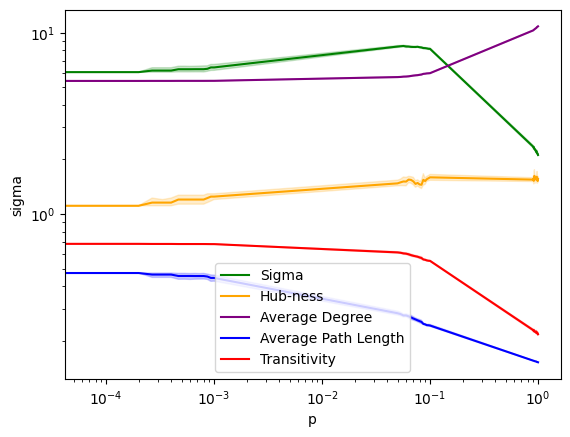

In [30]:
fig, ax = plt.subplots()
sns.lineplot(data=experiment_df, x='p', y='sigma', label='Sigma', color='green', ax=ax)
sns.lineplot(data=experiment_df, x='p', y='hub_ness', label='Hub-ness', color='orange', ax=ax)
sns.lineplot(data=experiment_df, x='p', y='k_avg', label='Average Degree', color='purple', ax=ax)
sns.lineplot(data=experiment_df, x='p', y='avg_length', label='Average Path Length', color='blue', ax=ax)
sns.lineplot(data=experiment_df, x='p', y='transitivity', label='Transitivity', color='red', ax=ax)
ax.set_xscale('log')
ax.set_yscale('log')
ax.legend()
plt.show()


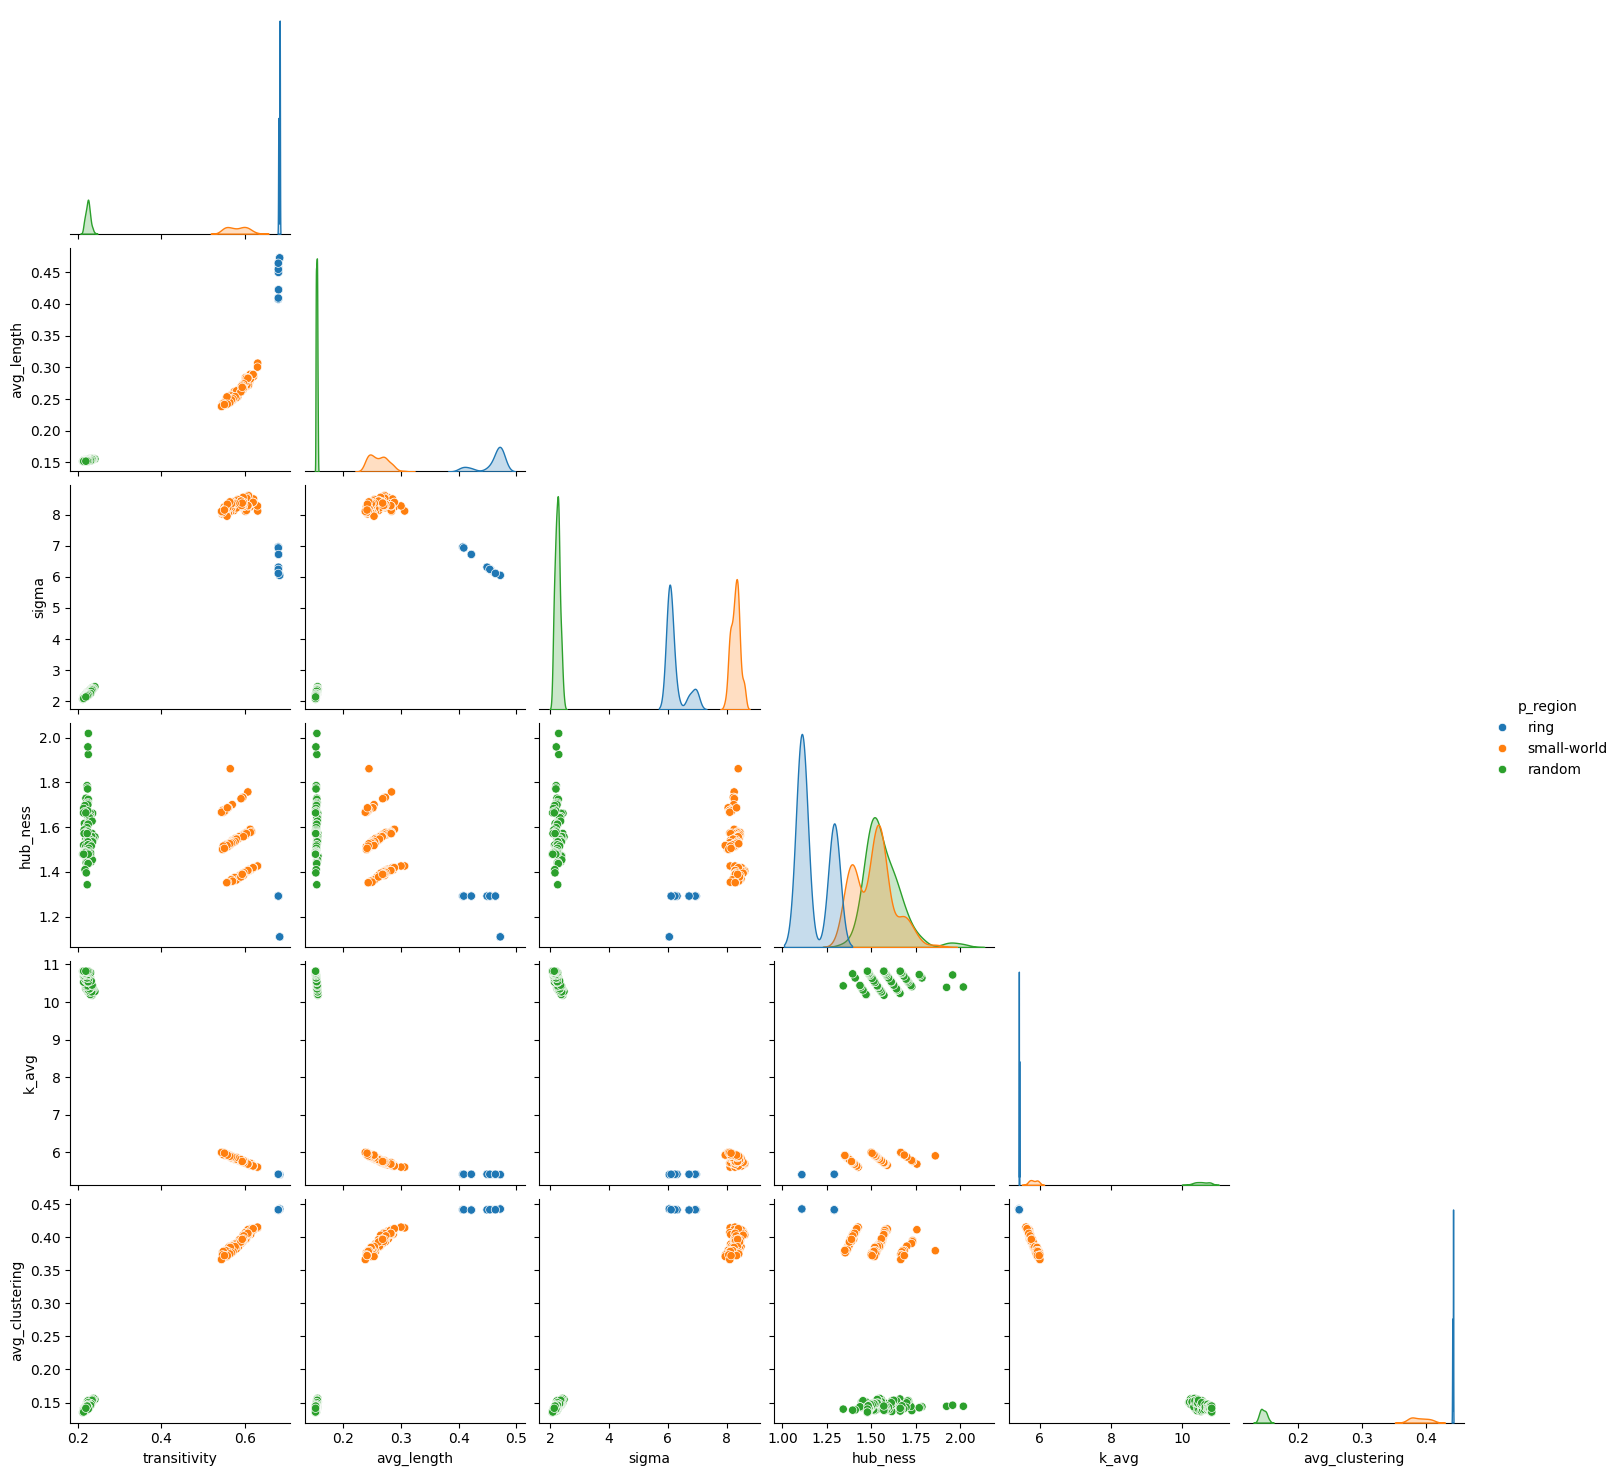

In [31]:
# Define regions of p
p_regions = {
    "ring": (0.0, 0.002),
    "small-world": (0.002, 0.2),
    "random": (0.2, 1.1),
}

# Add a new column to classify p into regions
experiment_df['p_region'] = experiment_df['p'].apply(
    lambda p: next((region for region, (low, high) in p_regions.items() if low <= p < high), "unknown")
)

# Pair plot for all data points, colored by p_region
# sns.pairplot(
#     data=experiment_df,
#     vars=['ipr_rho', 'ipr_O', 'ipr_eigenvector', 'variance_rho', 'variance_O', 'entropy_rho', 'entropy_O', 'weighted_k_avg_O', 'weighted_clustering_O', 'weighted_k_avg_rho', 'weighted_clustering_rho', 'transitivity', 'avg_length', 'sigma', 'hub_ness', 'k_avg', 'avg_clustering'],
#     hue='p_region', 
#     kind='scatter',
#     corner=True
# )

sns.pairplot(
    data=experiment_df,
    vars=['transitivity', 'avg_length', 'sigma', 'hub_ness', 'k_avg', 'avg_clustering'],
    hue='p_region', 
    kind='scatter',
    corner=True
)
plt.show()


In [32]:
# Create a new dataframe with columns: index_str, eigenvalue, index_eigenvalue, weighted_k_avg, weighted_clustering
# These values are saved as lists in the original dataframe, so we need to explode them (row: eigenvalue_0, weighted_k_avg_0, weighted_clustering_0), (row: eigenvalue_1, weighted_k_avg_1, weighted_clustering_1), etc.
# The index_eigenvalue is given by the position of the eigenvalue in the list of eigenvalues

import ast

# 1. Parse strings to lists (handles data loaded from CSV)
cols_to_explode = ['eigenvalues', 'weighted_k_avg', 'weighted_clustering', 'IPR_all_eigenvectors']
for col in cols_to_explode:
    experiment_df[col] = experiment_df[col].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

# 2. Reset index to make 'index_str' a regular column
df_reset = experiment_df.reset_index()

# 3. Explode the lists into rows simultaneously
exploded_df = df_reset.explode(cols_to_explode)

# 4. Create the 'index_eigenvalue' column based on the position in the original list
exploded_df['index_eigenvalue'] = exploded_df.groupby('index_str').cumcount()

# 5. Rename 'eigenvalues' to 'eigenvalue' and select the requested columns
exploded_df = exploded_df.rename(columns={'eigenvalues': 'eigenvalue'})
eigen_stats_df = exploded_df[['index_str', 'p_region', 'k_avg', 'avg_clustering', 'eigenvalue', 'index_eigenvalue', 'weighted_k_avg', 'weighted_clustering', 'IPR_all_eigenvectors']].reset_index(drop=True)

# Transform to numerical types 
eigen_stats_df['k_avg'] = pd.to_numeric(eigen_stats_df['k_avg'])
eigen_stats_df['avg_clustering'] = pd.to_numeric(eigen_stats_df['avg_clustering'])
eigen_stats_df['eigenvalue'] = pd.to_numeric(eigen_stats_df['eigenvalue'])
eigen_stats_df['index_eigenvalue'] = pd.to_numeric(eigen_stats_df['index_eigenvalue'])
eigen_stats_df['weighted_k_avg'] = pd.to_numeric(eigen_stats_df['weighted_k_avg'])
eigen_stats_df['weighted_clustering'] = pd.to_numeric(eigen_stats_df['weighted_clustering'])
eigen_stats_df['IPR_all_eigenvectors'] = pd.to_numeric(eigen_stats_df['IPR_all_eigenvectors'])
eigen_stats_df.head(10)

,index_str,p_region,k_avg,avg_clustering,eigenvalue,index_eigenvalue,weighted_k_avg,weighted_clustering,IPR_all_eigenvectors
0,p0.0_n200_k6_seed0,ring,5.41,0.442333,-8.905206,0,5.995882,0.400256,0.017171
1,p0.0_n200_k6_seed0,ring,5.41,0.442333,-8.895976,1,5.990690,0.400143,0.018414
2,p0.0_n200_k6_seed0,ring,5.41,0.442333,-8.821810,2,5.991997,0.400507,0.017253
3,p0.0_n200_k6_seed0,ring,5.41,0.442333,-8.813525,3,5.986730,0.400279,0.018380
4,p0.0_n200_k6_seed0,ring,5.41,0.442333,-8.716425,4,5.986943,0.400556,0.017119
5,p0.0_n200_k6_seed0,ring,5.41,0.442333,-8.691287,5,5.985279,0.400841,0.017446
6,p0.0_n200_k6_seed0,ring,5.41,0.442333,-8.687282,6,5.982698,0.400505,0.018085
7,p0.0_n200_k6_seed0,ring,5.41,0.442333,-8.683539,7,5.972526,0.400552,0.017814
8,p0.0_n200_k6_seed0,ring,5.41,0.442333,-8.628725,8,5.984283,0.401013,0.017016
9,p0.0_n200_k6_seed0,ring,5.41,0.442333,-8.594099,9,5.964028,0.400549,0.018631


In [33]:
# Divide each eigenvalue by avg_degree
eigen_stats_df['lamda/k_avg'] = eigen_stats_df['eigenvalue'] / eigen_stats_df['k_avg']
# Divide each weighted_k_avg by avg_degree
eigen_stats_df['weighted_k_avg/k_avg'] = eigen_stats_df['weighted_k_avg'] / eigen_stats_df['k_avg']
# Divide each weighted_clustering by avg_clustering
eigen_stats_df['weighted_clustering/avg_clustering'] = eigen_stats_df['weighted_clustering'] / eigen_stats_df['avg_clustering']
eigen_stats_df.head()

,index_str,p_region,k_avg,avg_clustering,eigenvalue,index_eigenvalue,weighted_k_avg,weighted_clustering,IPR_all_eigenvectors,lamda/k_avg,weighted_k_avg/k_avg,weighted_clustering/avg_clustering
0,p0.0_n200_k6_seed0,ring,5.41,0.442333,-8.905206,0,5.995882,0.400256,0.017171,-1.646064,1.108296,0.904874
1,p0.0_n200_k6_seed0,ring,5.41,0.442333,-8.895976,1,5.990690,0.400143,0.018414,-1.644358,1.107336,0.904618
2,p0.0_n200_k6_seed0,ring,5.41,0.442333,-8.821810,2,5.991997,0.400507,0.017253,-1.630649,1.107578,0.905441
3,p0.0_n200_k6_seed0,ring,5.41,0.442333,-8.813525,3,5.986730,0.400279,0.018380,-1.629117,1.106604,0.904927
4,p0.0_n200_k6_seed0,ring,5.41,0.442333,-8.716425,4,5.986943,0.400556,0.017119,-1.611169,1.106644,0.905552


In [34]:
eigen_stats_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76800 entries, 0 to 76799
Data columns (total 12 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   index_str                           76800 non-null  object 
 1   p_region                            76800 non-null  object 
 2   k_avg                               76800 non-null  float64
 3   avg_clustering                      76800 non-null  float64
 4   eigenvalue                          76800 non-null  float64
 5   index_eigenvalue                    76800 non-null  int64  
 6   weighted_k_avg                      76800 non-null  float64
 7   weighted_clustering                 76800 non-null  float64
 8   IPR_all_eigenvectors                76800 non-null  float64
 9   lamda/k_avg                         76800 non-null  float64
 10  weighted_k_avg/k_avg                76800 non-null  float64
 11  weighted_clustering/avg_clustering  76800

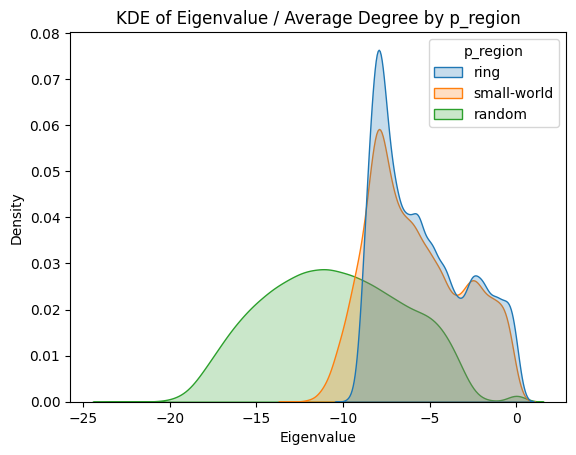

In [35]:
# Plot the kde frequency of lamda/k_avg for each p_region
sns.kdeplot(data=eigen_stats_df, x='eigenvalue', hue='p_region', fill=True)
plt.title('KDE of Eigenvalue / Average Degree by p_region')
plt.xlabel('Eigenvalue')
plt.ylabel('Density')
plt.show()

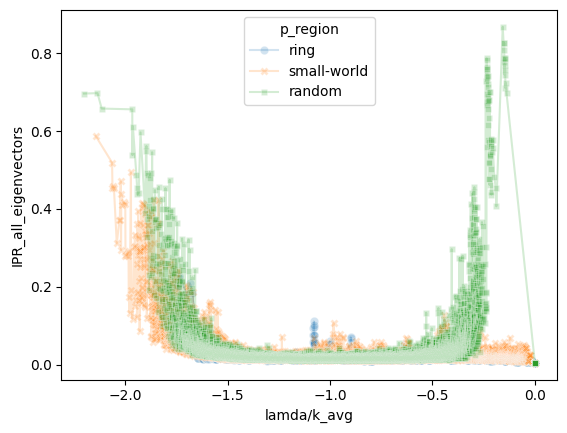

In [36]:
sns.lineplot(
    data=eigen_stats_df,
    x='lamda/k_avg',
    y='IPR_all_eigenvectors',
    hue='p_region',
    style='p_region',
    markers=True,
    dashes=False,
    alpha=0.2
)
plt.show()

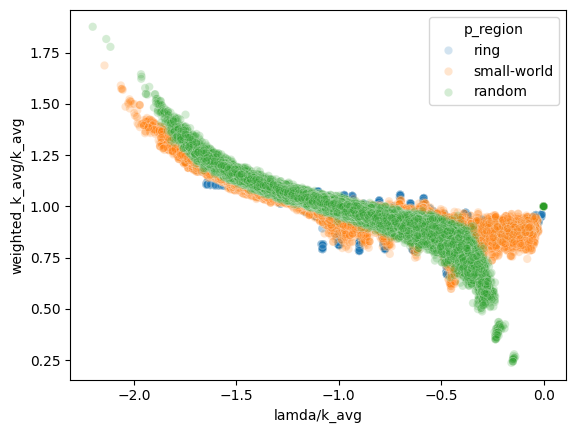

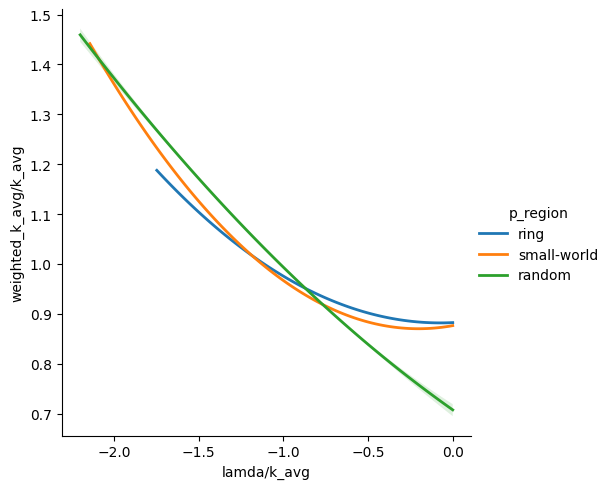

In [37]:
sns.scatterplot(
    data=eigen_stats_df,
    x='lamda/k_avg',
    y='weighted_k_avg/k_avg',
    hue='p_region',
    alpha=0.2  # Increase transparency
)
plt.show()



sns.lmplot(
    data=eigen_stats_df,
    x='lamda/k_avg',
    y='weighted_k_avg/k_avg',
    hue='p_region',
    order=2,
    scatter=False,          # hide data points
    line_kws={'lw': 2}      # optional: make regression curves clearer
)
plt.show()

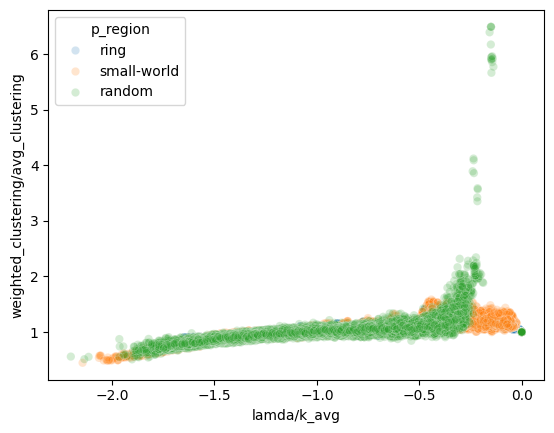

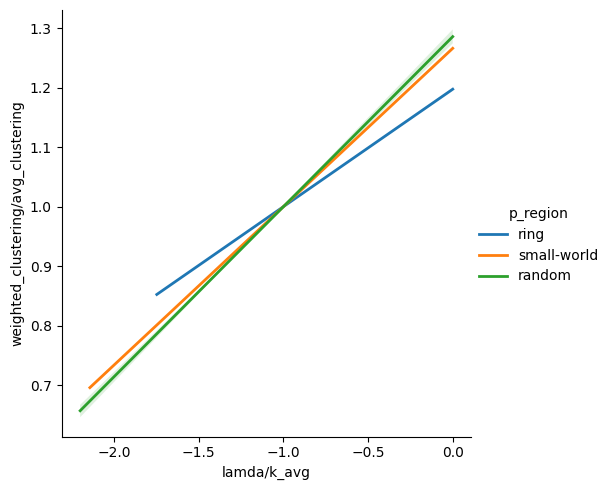

In [38]:
sns.scatterplot(
    data=eigen_stats_df,
    x='lamda/k_avg',
    y='weighted_clustering/avg_clustering',
    hue='p_region',
    alpha=0.2  # Increase transparency
)
plt.show()



sns.lmplot(
    data=eigen_stats_df,
    x='lamda/k_avg',
    y='weighted_clustering/avg_clustering',
    hue='p_region',
    order=1,
    scatter=False,          # hide data points
    line_kws={'lw': 2},      # optional: make regression curves clearer
    scatter_kws={'alpha': 0.1}  # Increase transparency of data points
)
plt.show()